In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [50]:
df = pd.read_csv("fire.csv")

C:\Users\Elowe\AppData\Local\Temp\ipykernel_19496\2948116887.py:1: DtypeWarning:

Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.



In [51]:
df.columns

Index(['_id', 'Incident_Number', 'Initial_CAD_Event_Type',
       'Final_Incident_Type', 'Exposures', 'Incident_Station_Area',
       'Incident_Ward', 'Intersection', 'Latitude', 'Longitude',
       'Property_Use', 'Building_Status', 'TFS_Alarm_Time', 'TFS_Arrival_Time',
       'Ext_agent_app_or_defer_time', 'Fire_Under_Control_Time',
       'Last_TFS_Unit_Clear_Time', 'Number_of_responding_apparatus',
       'Number_of_responding_personnel', 'Count_of_Persons_Rescued',
       'TFS_Firefighter_Casualties', 'Civilian_Casualties',
       'Estimated_Number_Of_Persons_Displaced', 'Estimated_Dollar_Loss',
       'Business_Impact', 'Status_of_Fire_On_Arrival',
       'Method_Of_Fire_Control', 'Area_of_Origin', 'Level_Of_Origin',
       'Extent_Of_Fire', 'Smoke_Spread', 'Ignition_Source',
       'Material_First_Ignited', 'Possible_Cause',
       'Smoke_Alarm_at_Fire_Origin',
       'Smoke_Alarm_at_Fire_Origin_Alarm_Failure',
       'Smoke_Alarm_at_Fire_Origin_Alarm_Type',
       'Smoke_Alarm_

In [52]:
from sklearn.model_selection import train_test_split
time_cols = ['TFS_Alarm_Time', 'TFS_Arrival_Time', 'Fire_Under_Control_Time', 'Hourly_Timestamp']
for col in time_cols:
    df[col] = pd.to_datetime(df[col])

df['Control_Duration'] = (df['Fire_Under_Control_Time'] - df['TFS_Arrival_Time']).dt.total_seconds()

df['Hour_of_Day'] = df['Hourly_Timestamp'].dt.hour
df['is_weekend'] = df['Hourly_Timestamp'].dt.dayofweek >= 5

def categorize_event(x):
    x = str(x)
    if "Fire" in x or x.startswith("FI"):
        return "Fire"
    else:
        return "Other"

df["Event_Category"] = df["Initial_CAD_Event_Type"].apply(categorize_event)
df = df[df["Event_Category"]=="Fire"]

df_train_val, df_test = train_test_split(df, test_size=0.2, random_state=42)
df_train, df_val = train_test_split(df_train_val, test_size=0.2, random_state=42)

df_analysis = df_train[(df_train['Control_Duration'] > 0) & (df_train['Control_Duration'] < 14400)].copy()
df_analysis['Incident_Station_Area'] = df_analysis['Incident_Station_Area'].astype(int)

In [53]:
df_analysis.isnull().sum()

_id                                                                 0
Incident_Number                                                     0
Initial_CAD_Event_Type                                              0
Final_Incident_Type                                                 0
Exposures                                                        8641
Incident_Station_Area                                               0
Incident_Ward                                                      33
Intersection                                                        0
Latitude                                                            0
Longitude                                                           0
Property_Use                                                        0
Building_Status                                                  2762
TFS_Alarm_Time                                                      0
TFS_Arrival_Time                                                    0
Ext_agent_app_or_def

Examine the target variable

In [54]:
df_analysis['Estimated_Dollar_Loss'].describe()

count    1.120000e+04
mean     3.830575e+04
std      2.093271e+05
min      0.000000e+00
25%      3.000000e+02
50%      3.000000e+03
75%      2.000000e+04
max      1.300000e+07
Name: Estimated_Dollar_Loss, dtype: float64

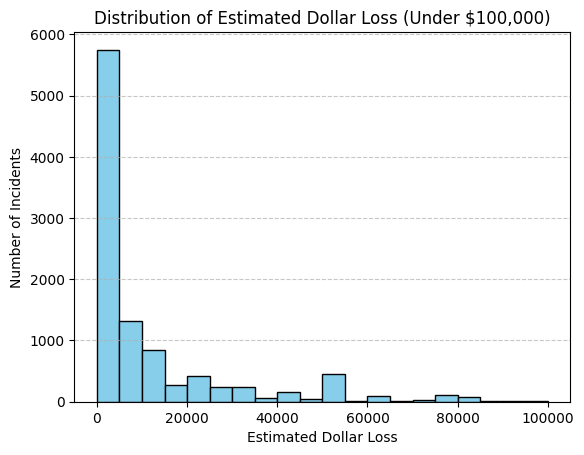

In [55]:
plt.hist(df_analysis[df_analysis["Estimated_Dollar_Loss"] < 1e5]["Estimated_Dollar_Loss"], 
         bins=20, color='skyblue', edgecolor='black')

plt.title('Distribution of Estimated Dollar Loss (Under $100,000)')
plt.xlabel('Estimated Dollar Loss')
plt.ylabel('Number of Incidents')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Examine some Categorical values

In [56]:
print(df_analysis["Initial_CAD_Event_Type"].value_counts())

Initial_CAD_Event_Type
FIR                                       3197
FIHR                                      1426
Fire - Residential                        1279
FIG                                       1079
FICI                                      1073
Vehicle Fire                               669
Fire -  Highrise Residential               501
Fire - Grass/Rubbish                       431
Fire - Commercial/Industrial               415
Vehicle Fire - Highway                     229
FIHRD                                      117
FITP                                        97
FIO                                         94
FIS                                         80
FIOS                                        51
FIHV                                        41
FIG2                                        40
FII                                         39
Fire - Highrise Residential - Downtown      34
Fire - Transformer/Pole                     32
Fire - Other                         

In [57]:
print(df_analysis["Property_Use"].value_counts())

Property_Use
301 - Detached Dwelling                                    2021
323 - Multi-Unit Dwelling - Over 12 Units                  1815
302 - Semi-Detached Dwelling                                623
848 - Trash/Rubbish/Garbage Container or Dumpster           566
323 - Multi-Unit Dwelling Over 12 Units                     544
                                                           ... 
735 - Sto: Job Printing (eg forms, greeting cards, etc)       1
626 - Mfg:Rubber Goods                                        1
232 - Halfway/transitional house                              1
206 - Psychiatric Hospital (with detention quarters)          1
529 - Book/Stationary/Art Supply Store                        1
Name: count, Length: 307, dtype: int64


In [58]:
print(df_analysis["Building_Status"].value_counts())

Building_Status
01 - Normal (no change)               7251
08 - Not Applicable                    510
02 - Under Renovation                  395
03 - Under Construction                116
05 - Abandoned, vacant (long term)      93
09 - Undetermined                       86
04 - Under Demolition                   12
Name: count, dtype: int64


EDA with Visuals

In [59]:
df_analysis.dtypes

_id                                                                       int64
Incident_Number                                                          object
Initial_CAD_Event_Type                                                   object
Final_Incident_Type                                                      object
Exposures                                                               float64
Incident_Station_Area                                                     int32
Incident_Ward                                                           float64
Intersection                                                             object
Latitude                                                                float64
Longitude                                                               float64
Property_Use                                                             object
Building_Status                                                          object
TFS_Alarm_Time                          

In [60]:
df_analysis.describe()

,_id,Exposures,Incident_Station_Area,Incident_Ward,Latitude,Longitude,TFS_Alarm_Time,TFS_Arrival_Time,Fire_Under_Control_Time,Number_of_responding_apparatus,...,Civilian_Casualties,Estimated_Number_Of_Persons_Displaced,Estimated_Dollar_Loss,Duration,Hourly_Timestamp,temperature_2m,snowfall,precipitation,Control_Duration,Hour_of_Day
count,11225.000000,2584.000000,11225.000000,11192.000000,11225.000000,11225.000000,11225,11225,11225,11225.000000,...,8999.000000,8463.000000,1.120000e+04,11225.000000,11225,11225.000000,11225.000000,11225.000000,11225.000000,11225.000000
mean,16587.736927,0.185759,285.480000,16.034221,43.703957,-79.395496,2018-03-01 03:50:32.368908800,2018-03-01 03:55:44.436614656,2018-03-01 04:09:37.970512384,8.685702,...,0.091566,18.666076,3.830575e+04,312.067706,2018-03-01 03:20:17.104677120,9.986227,0.009616,0.086111,833.533898,13.111269
min,2.000000,0.000000,111.000000,0.000000,0.000000,-79.636530,2011-01-01 00:06:48,2011-01-01 00:12:54,2011-01-01 01:54:00,0.000000,...,0.000000,0.000000,0.000000e+00,-962.000000,2011-01-01 00:00:00,-24.500000,0.000000,0.000000,1.000000,0.000000
25%,8611.000000,0.000000,213.000000,7.000000,43.663540,-79.481987,2014-08-22 11:42:14,2014-08-22 11:45:44,2014-08-22 11:53:12,5.000000,...,0.000000,0.000000,3.000000e+02,251.000000,2014-08-22 11:00:00,1.800000,0.000000,0.000000,190.000000,8.000000
50%,15362.000000,0.000000,313.000000,14.000000,43.701640,-79.406573,2018-07-04 17:21:04,2018-07-04 17:26:52,2018-07-04 17:29:57,6.000000,...,0.000000,0.000000,3.000000e+03,301.000000,2018-07-04 17:00:00,9.800000,0.000000,0.000000,404.000000,14.000000
75%,24240.000000,0.000000,411.000000,23.000000,43.751360,-79.331410,2021-06-14 03:35:50,2021-06-14 03:41:31,2021-06-14 03:47:34,11.000000,...,0.000000,2.000000,2.000000e+04,360.000000,2021-06-14 03:00:00,19.100000,0.000000,0.000000,864.000000,19.000000
max,36543.000000,6.000000,445.000000,44.000000,43.855400,0.000000,2024-12-31 22:51:15,2024-12-31 22:55:05,2024-12-31 23:39:00,175.000000,...,6.000000,999.000000,1.300000e+07,17871.000000,2024-12-31 22:00:00,33.300000,3.360000,8.500000,14379.000000,23.000000
std,9864.898087,0.583963,109.258451,10.702874,0.415917,0.756686,NaN,NaN,NaN,7.449337,...,0.375179,126.952297,2.093271e+05,201.929674,NaN,10.494446,0.086190,0.386696,1337.064360,6.630415


In [61]:
import plotly.express as px

df_map = df_analysis.dropna(subset=['Latitude', 'Longitude', 'Control_Duration', "Estimated_Dollar_Loss"])

df_map = df_map[df_map['Control_Duration'] < 7200]

fig = px.scatter_mapbox(df_map, 
                        lat="Latitude", 
                        lon="Longitude", 
                        color="Control_Duration", 
                        size="Estimated_Dollar_Loss",
                        color_continuous_scale=px.colors.cyclical.IceFire, 
                        size_max=15, 
                        zoom=10,
                        mapbox_style="carto-positron",
                        title="Fire distribution",
                        hover_data=['Final_Incident_Type', 'Property_Use'])
fig.show()

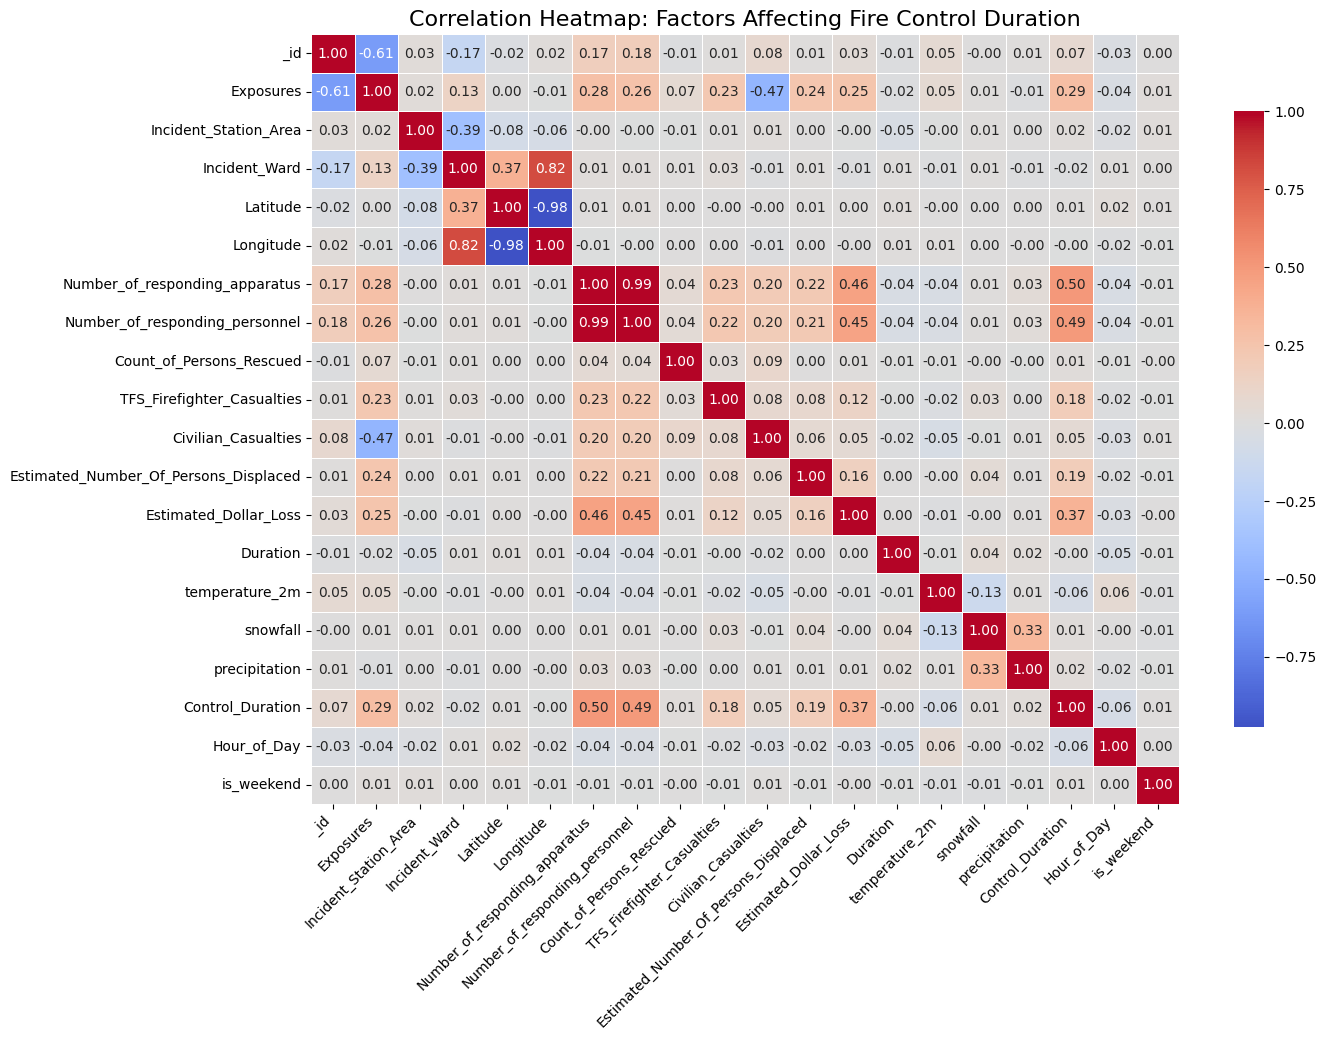

In [62]:
corr_matrix = df_analysis.corr(numeric_only=True)
plt.figure(figsize=(14, 10))

sns.heatmap(corr_matrix, 
            annot=True,
            fmt=".2f",
            cmap='coolwarm', 
            center=0,
            linewidths=.5, 
            cbar_kws={"shrink": .8})

plt.title('Correlation Heatmap: Factors Affecting Fire Control Duration', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.show()

Text(0, 0.5, 'Frequency')

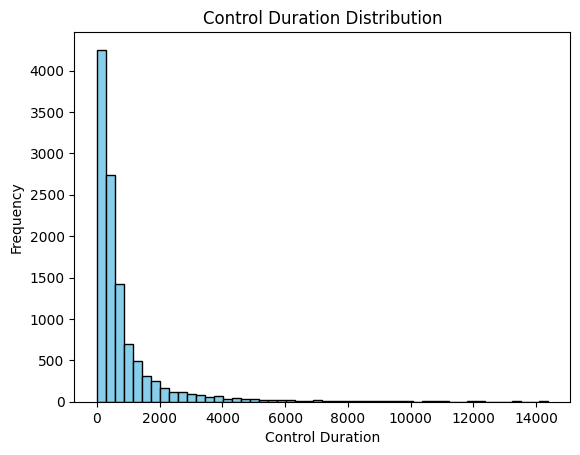

In [63]:
plt.hist(df_analysis["Control_Duration"], bins=50, color='skyblue', edgecolor='black')
plt.title("Control Duration Distribution")
plt.xlabel("Control Duration")
plt.ylabel("Frequency")

In [64]:
df_analysis['Property_Use'].value_counts()

Property_Use
301 - Detached Dwelling                                    2021
323 - Multi-Unit Dwelling - Over 12 Units                  1815
302 - Semi-Detached Dwelling                                623
848 - Trash/Rubbish/Garbage Container or Dumpster           566
323 - Multi-Unit Dwelling Over 12 Units                     544
                                                           ... 
735 - Sto: Job Printing (eg forms, greeting cards, etc)       1
626 - Mfg:Rubber Goods                                        1
232 - Halfway/transitional house                              1
206 - Psychiatric Hospital (with detention quarters)          1
529 - Book/Stationary/Art Supply Store                        1
Name: count, Length: 307, dtype: int64

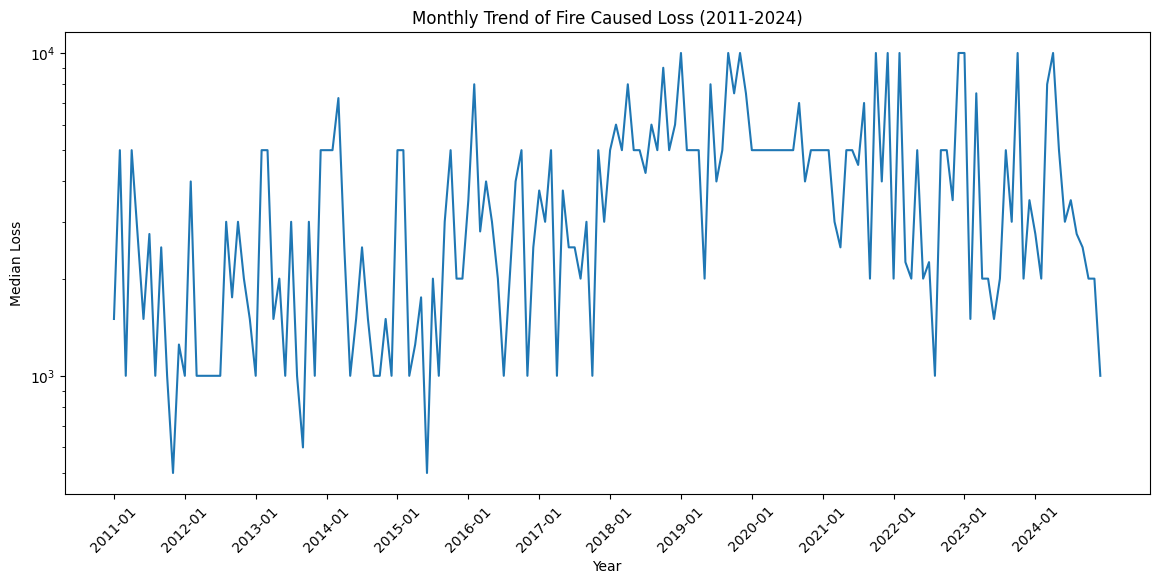

In [65]:
df_analysis["Year_Month"] = df_analysis["TFS_Alarm_Time"].dt.to_period("M")
monthly_loss = (
    df_analysis
    .groupby("Year_Month")["Estimated_Dollar_Loss"]
    .median()
    .reset_index()
)

monthly_loss["Year_Month"] = monthly_loss["Year_Month"].astype(str)
plt.figure(figsize=(14,6))
sns.lineplot(
    data=monthly_loss,
    x=range(len(monthly_loss)),
    y="Estimated_Dollar_Loss"
)
plt.yscale("log")
plt.xticks(
    ticks=range(0, len(monthly_loss), 12),
    labels=monthly_loss["Year_Month"][::12],
    rotation=45
)
plt.xlabel("Year")
plt.ylabel("Median Loss")
plt.title("Monthly Trend of Fire Caused Loss (2011-2024)")
plt.show()

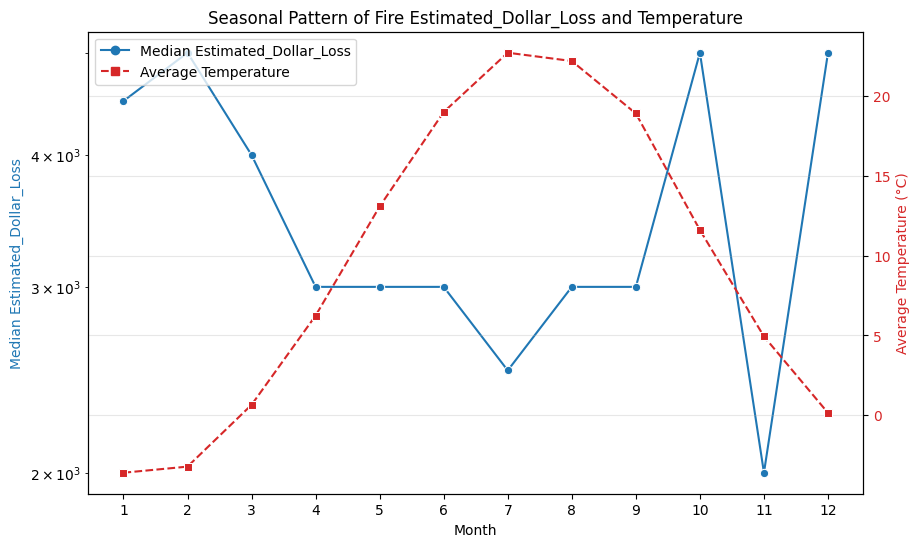

In [66]:
from matplotlib.lines import Line2D
df_analysis["Month"] = df_analysis["TFS_Alarm_Time"].dt.month
monthly_stats = (
    df_analysis
    .groupby("Month")
    .agg(
        median_loss=("Estimated_Dollar_Loss", "median"),
        mean_temperature=("temperature_2m", "mean")
    )
    .reset_index()
)
fig, ax1 = plt.subplots(figsize=(10,6))
line1 = sns.lineplot(
    data=monthly_stats,
    x="Month",
    y="median_loss",
    marker="o",
    ax=ax1,
    color="tab:blue"
)

ax1.set_yscale("log")
ax1.set_xlabel("Month")
ax1.set_ylabel("Median Estimated_Dollar_Loss", color="tab:blue")
ax1.set_xticks(range(1,13))
ax1.set_title("Seasonal Pattern of Fire Estimated_Dollar_Loss and Temperature")
ax1.tick_params(axis='y', labelcolor="tab:blue")

ax2 = ax1.twinx()
line2 = sns.lineplot(
    data=monthly_stats,
    x="Month",
    y="mean_temperature",
    marker="s",
    linestyle="--",
    ax=ax2,
    color="tab:red"
)

ax2.set_ylabel("Average Temperature (°C)", color="tab:red")
ax2.tick_params(axis='y', labelcolor="tab:red")
legend_elements = [
    Line2D([0], [0], color="tab:blue", marker="o", label="Median Estimated_Dollar_Loss"),
    Line2D([0], [0], color="tab:red", marker="s", linestyle="--", label="Average Temperature")
]
ax1.legend(handles=legend_elements, loc="upper left")

plt.grid(alpha=0.3)
plt.show()

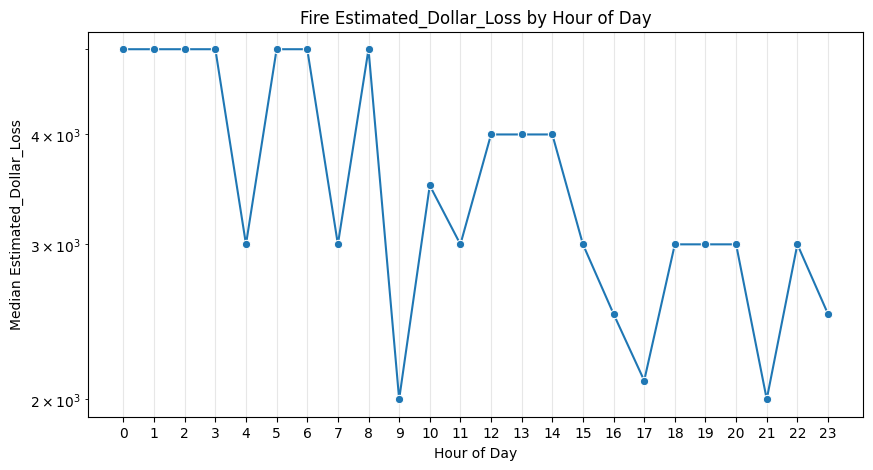

In [67]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=df_analysis,
    x="Hour_of_Day",
    y="Estimated_Dollar_Loss",
    estimator="median",
    errorbar=None,
    marker="o"
)

plt.yscale("log")
plt.xticks(range(24))
plt.xlabel("Hour of Day")
plt.ylabel("Median Estimated_Dollar_Loss")
plt.title("Fire Estimated_Dollar_Loss by Hour of Day")
plt.grid(alpha=0.3)

plt.show()

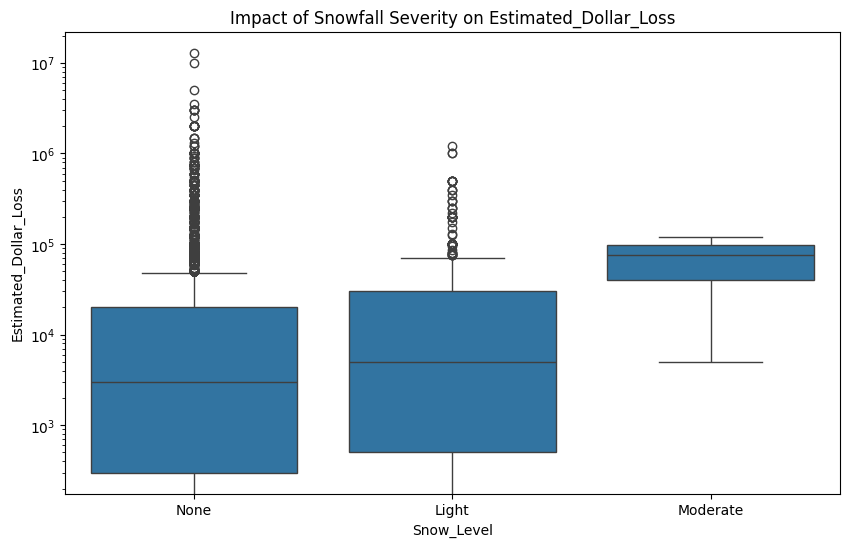

In [68]:
df_analysis['Snow_Level'] = pd.cut(df_analysis['snowfall'], 
                                   bins=[-1, 0, 2, 5], 
                                   labels=['None', 'Light', 'Moderate'])

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_analysis, x='Snow_Level', y='Estimated_Dollar_Loss')
plt.title('Impact of Snowfall Severity on Estimated_Dollar_Loss')
plt.yscale('log')
plt.show()

In [69]:
df_analysis['precipitation'].describe()

count    11225.000000
mean         0.086111
std          0.386696
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          8.500000
Name: precipitation, dtype: float64

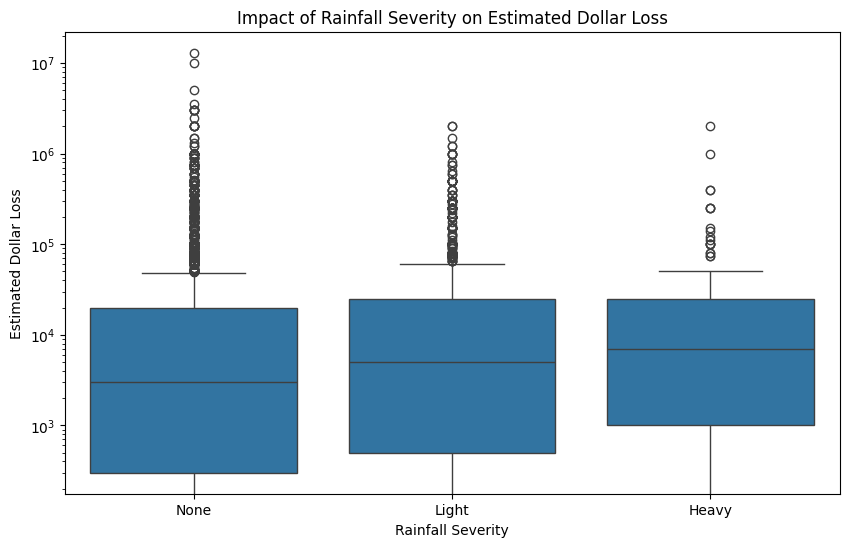

In [70]:
df_analysis['Rain_Level'] = pd.cut(
    df_analysis['precipitation'],
    bins=[-1, 0, 2, 5],
    labels=['None', 'Light', 'Heavy']
)

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_analysis, x='Rain_Level', y='Estimated_Dollar_Loss')
plt.title('Impact of Rainfall Severity on Estimated Dollar Loss')
plt.yscale('log')
plt.xlabel("Rainfall Severity")
plt.ylabel("Estimated Dollar Loss")
plt.show()

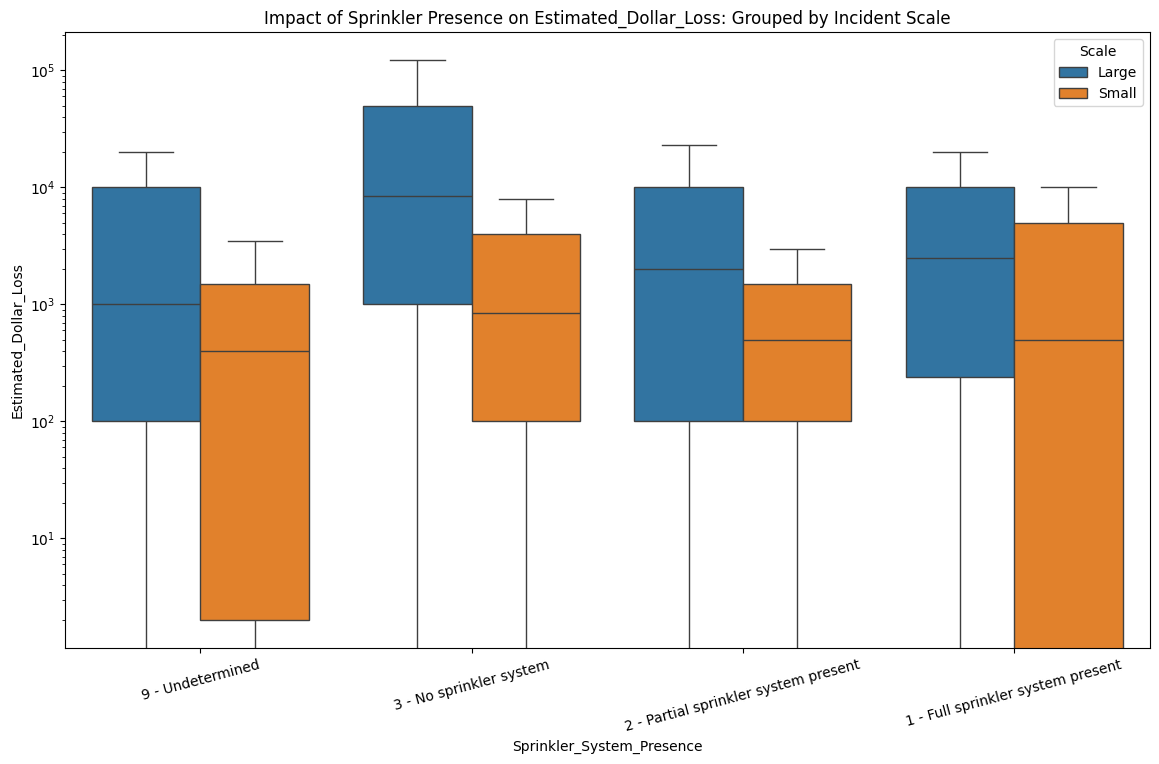

In [71]:
order = [
    '9 - Undetermined', 
    '3 - No sprinkler system', 
    '2 - Partial sprinkler system present', 
    '1 - Full sprinkler system present'
]
df_analysis['Scale'] = df_analysis['Number_of_responding_apparatus'].apply(lambda x: 'Small' if x <= 5 else 'Large')

plt.figure(figsize=(14, 8))
sns.boxplot(
    data=df_analysis, 
    x='Sprinkler_System_Presence', 
    y='Estimated_Dollar_Loss', 
    hue='Scale',
    order=order,
    showfliers=False
)
plt.title('Impact of Sprinkler Presence on Estimated_Dollar_Loss: Grouped by Incident Scale')
plt.xticks(rotation=15)
plt.yscale("log")
plt.show()

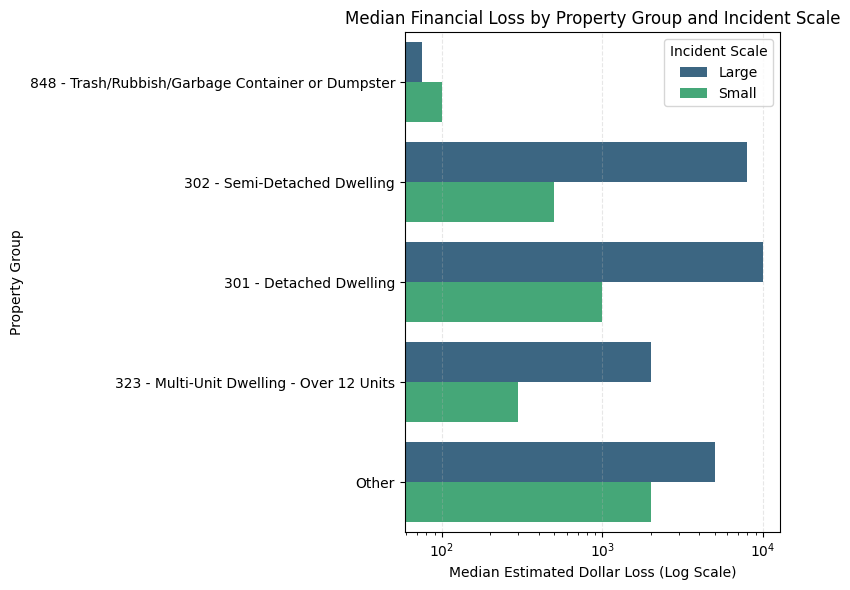

In [72]:
top_property = df_analysis["Property_Use"].value_counts().nlargest(4).index

df_analysis["Property_Group"] = df_analysis["Property_Use"].where(
    df_analysis["Property_Use"].isin(top_property),
    "Other"
)
order = [
    '848 - Trash/Rubbish/Garbage Container or Dumpster',
    '302 - Semi-Detached Dwelling', 
    '301 - Detached Dwelling',
    '323 - Multi-Unit Dwelling - Over 12 Units', 
    'Other'
]

plt.figure(figsize=(8, 6))

sns.barplot(
    data=df_analysis, 
    y='Property_Group',
    x='Estimated_Dollar_Loss',
    hue='Scale', 
    estimator='median',
    order=order,
    errorbar=None,
    palette="viridis"
)

plt.xscale('log')
plt.title('Median Financial Loss by Property Group and Incident Scale')
plt.xlabel('Median Estimated Dollar Loss (Log Scale)')
plt.ylabel('Property Group')
plt.legend(title='Incident Scale')

plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

GAM for non-linear relationship

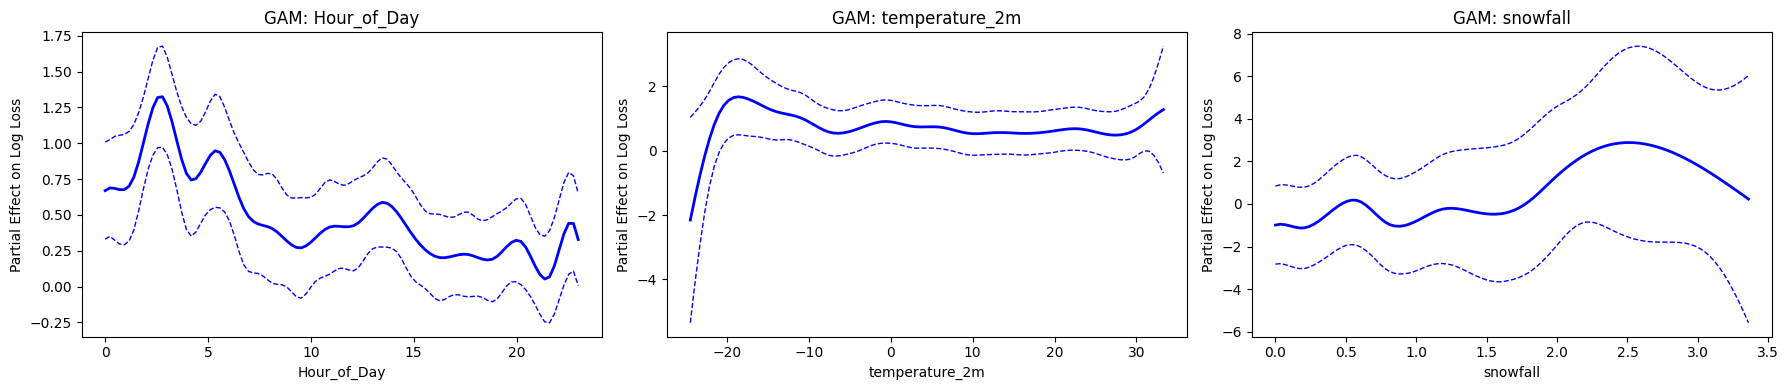

In [73]:
from pygam import LinearGAM, s
import numpy as np
import matplotlib.pyplot as plt

df_gam = df_analysis[['Hour_of_Day', 'temperature_2m', 'snowfall', 'Estimated_Dollar_Loss']].dropna()
X = df_gam[['Hour_of_Day', 'temperature_2m', 'snowfall']].values
y = np.log1p(df_gam['Estimated_Dollar_Loss'].values)

gam = LinearGAM(
    s(0, n_splines=20) +  # Hour_of_Day
    s(1, n_splines=20) +  # temperature_2m
    s(2, n_splines=20)    # snowfall
).fit(X, y)

features = ['Hour_of_Day', 'temperature_2m', 'snowfall']
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for i, ax in enumerate(axes):
    XX = gam.generate_X_grid(term=i)
    pd_effect = gam.partial_dependence(term=i, X=XX)
    _, ci = gam.partial_dependence(term=i, X=XX, width=0.95)

    x_axis = XX[:, i]
    ax.plot(x_axis, pd_effect, color='blue', lw=2)
    ax.plot(x_axis, ci, color='blue', ls="--", lw=1)
    ax.set_xlabel(features[i])
    ax.set_ylabel("Partial Effect on Log Loss")
    ax.set_title(f"GAM: {features[i]}")

plt.tight_layout()
plt.show()

Preliminary Predictive Modeling

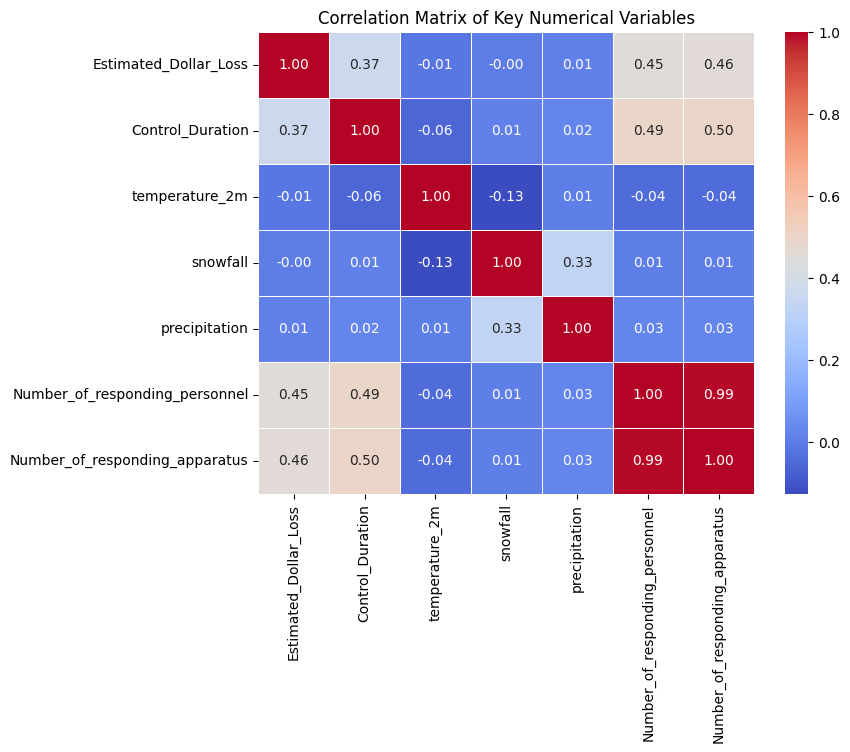

In [74]:
numeric_cols = [
    "Estimated_Dollar_Loss",
    "Control_Duration",
    "temperature_2m",
    "snowfall",
    "precipitation",
    "Number_of_responding_personnel",
    "Number_of_responding_apparatus",  
]

corr_matrix = df_analysis[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Key Numerical Variables")
plt.show()

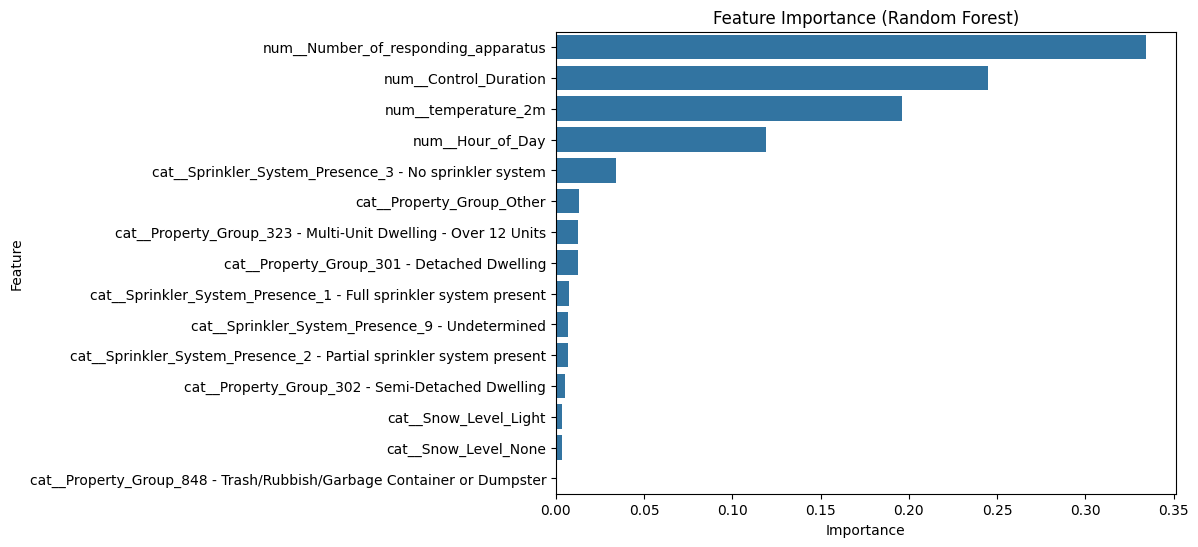

In [75]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

features = [
    "Control_Duration",
    "temperature_2m",
    "Snow_Level",
    "Number_of_responding_apparatus",
    "Hour_of_Day",
    "Sprinkler_System_Presence",
    "Property_Group",
    "Estimated_Dollar_Loss"
]

df_model = df_analysis[features].dropna()
X = df_model.drop(columns=["Estimated_Dollar_Loss"])
y = np.log1p(df_model["Estimated_Dollar_Loss"])

categorical = [
    "Sprinkler_System_Presence",
    "Property_Group",
    "Snow_Level"
]

numeric = [
    "Control_Duration",
    "temperature_2m",
    "Number_of_responding_apparatus",
    "Hour_of_Day"
]

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
        ("num", "passthrough", numeric)
    ]
)

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

pipeline = Pipeline([
    ("prep", preprocess),
    ("model", model)
])

pipeline.fit(X, y)

rf = pipeline.named_steps["model"]
feature_names = pipeline.named_steps["prep"].get_feature_names_out()

importances = pd.Series(
    rf.feature_importances_,
    index=feature_names
).sort_values(ascending=False).head(15)

plt.figure(figsize=(8,6))
sns.barplot(
    x=importances.values,
    y=importances.index
)

plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [76]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

df_model = df_analysis[features].dropna()

X_train = df_model.drop(columns=["Estimated_Dollar_Loss"])
y_train = np.log1p(df_model["Estimated_Dollar_Loss"])

df_val['Snow_Level'] = pd.cut(df_val['snowfall'], 
                            bins=[-1, 0, 2, 5], 
                            labels=['None', 'Light', 'Moderate'])
df_val["Property_Group"] = df_val["Property_Use"].where(
    df_val["Property_Use"].isin(top_property),
    "Other"
)
df_val_model = df_val[features].dropna()

X_val = df_val_model.drop(columns=["Estimated_Dollar_Loss"])
y_val = np.log1p(df_val_model["Estimated_Dollar_Loss"])
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
        ("num", "passthrough", numeric)
    ]
)
xgb_model = XGBRegressor(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
pipeline = Pipeline([
    ("prep", preprocess),
    ("model", xgb_model)
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, y_pred))
r2 = r2_score(y_val, y_pred)

print("Validation RMSE:", rmse)
print("Validation R2:", r2)

Validation RMSE: 2.8068175702684486
Validation R2: 0.3558022837668545


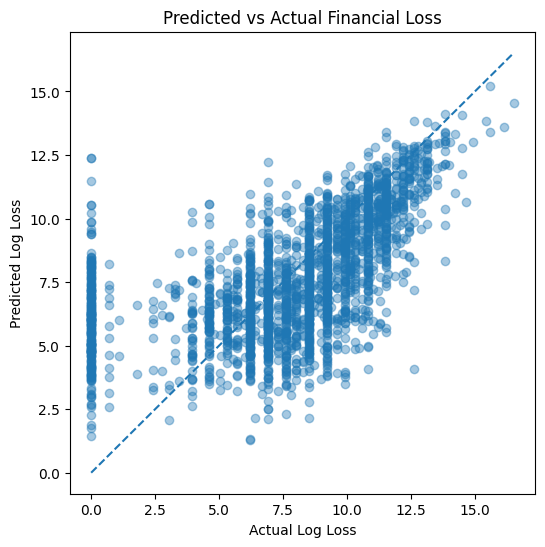

In [77]:
plt.figure(figsize=(6,6))

plt.scatter(y_val, y_pred, alpha=0.4)

plt.xlabel("Actual Log Loss")
plt.ylabel("Predicted Log Loss")

plt.title("Predicted vs Actual Financial Loss")

plt.plot(
    [y_val.min(), y_val.max()],
    [y_val.min(), y_val.max()],
    linestyle="--"
)

plt.show()

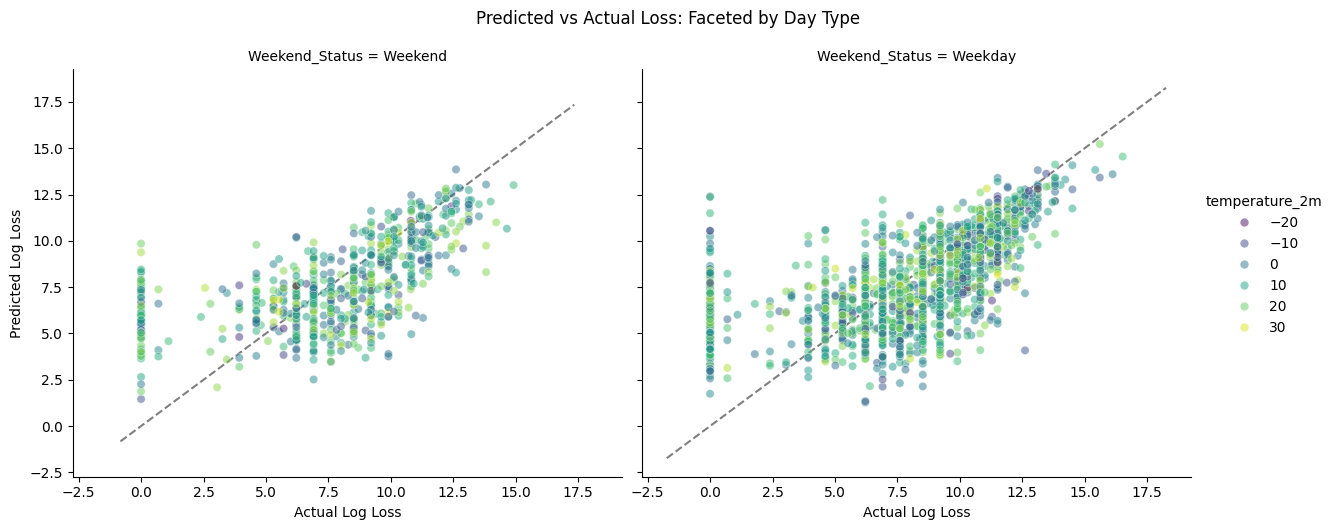

In [82]:
df_val_plot = df_val.copy()
df_val_plot['Snow_Level'] = pd.cut(df_val_plot['snowfall'], 
                                 bins=[-1, 0, 2, 5], 
                                 labels=['None', 'Light', 'Moderate'])
df_val_plot["Property_Group"] = df_val_plot["Property_Use"].where(
    df_val_plot["Property_Use"].isin(top_property), "Other"
)


plot_data_subset = df_val_plot[features + ['is_weekend']].dropna()

X_val_final = plot_data_subset.drop(columns=["Estimated_Dollar_Loss", "is_weekend"])
y_val_final = np.log1p(plot_data_subset["Estimated_Dollar_Loss"])

y_pred_final = pipeline.predict(X_val_final)

plot_df = plot_data_subset.copy()
plot_df['Actual_Log_Loss'] = y_val_final
plot_df['Predicted_Log_Loss'] = y_pred_final
plot_df['Weekend_Status'] = plot_df['is_weekend'].map({True: 'Weekend', False: 'Weekday'})

g = sns.relplot(
    data=plot_df,
    x="Actual_Log_Loss",
    y="Predicted_Log_Loss",
    col="Weekend_Status",
    hue="temperature_2m",
    alpha=0.5,
    palette="viridis",
    kind="scatter",
    height=5,
    aspect=1.2
)

for ax in g.axes.flat:
    lims = [
        np.min([ax.get_xlim(), ax.get_ylim()]),
        np.max([ax.get_xlim(), ax.get_ylim()]),
    ]
    ax.plot(lims, lims, '--k', alpha=0.5, zorder=0, label='Perfect Prediction')
    ax.set_xlabel("Actual Log Loss")
    ax.set_ylabel("Predicted Log Loss")

g.fig.suptitle("Predicted vs Actual Loss: Faceted by Day Type", y=1.05)
plt.show()